In [1]:
print("HELLO")

HELLO


In [2]:
import pandas as pd

print("Pandas loaded successfully!")
print("Version:", pd.__version__)

Pandas loaded successfully!
Version: 3.0.5


In [3]:
df = pd.read_csv("../data/processed/behavior_features.csv")

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (14368, 20)


In [4]:
print("Class distribution:")
print(df["label"].value_counts())

print("\nClass percentages:")
print((df["label"].value_counts(normalize=True) * 100).round(2))

Class distribution:
label
1    10894
0     3474
Name: count, dtype: int64

Class percentages:
label
1    75.82
0    24.18
Name: proportion, dtype: float64


In [5]:
features = [
    "statuses_count",
    "followers_count",
    "friends_count",
    "favourites_count",
    "listed_count",
    "account_age_days",
    "statuses_per_day",
    "followers_friends_ratio",
    "friends_followers_ratio",
    "favorites_per_status",
    "log_statuses_count",
    "log_followers_count",
    "log_friends_count",
    "log_favourites_count",
    "log_listed_count"
]

X = df[features]
y = df["label"]

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 15
X shape: (14368, 15)
y shape: (14368,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

NameError: name 'train_test_split' is not defined

In [10]:
import sys

print("Notebook Python:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Notebook Python:
c:\Users\namit\AppData\Local\Programs\Python\Python314\python.exe

Python version:
3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]


In [1]:
import sklearn

print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.9.0


In [2]:
from sklearn.model_selection import train_test_split

print("train_test_split loaded successfully!")

train_test_split loaded successfully!


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

print("All imports successful!")

All imports successful!


In [7]:
df = pd.read_csv("../data/processed/behavior_features.csv")

print("Shape:", df.shape)

Shape: (14368, 20)


In [8]:
features = [
    "statuses_count",
    "followers_count",
    "friends_count",
    "favourites_count",
    "listed_count",
    "account_age_days",
    "statuses_per_day",
    "followers_friends_ratio",
    "friends_followers_ratio",
    "favorites_per_status",
    "log_statuses_count",
    "log_followers_count",
    "log_friends_count",
    "log_favourites_count",
    "log_listed_count"
]

X = df[features]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (14368, 15)
y shape: (14368,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training set: (11494, 15)
Test set: (2874, 15)

Training distribution:
label
1    8715
0    2779
Name: count, dtype: int64

Test distribution:
label
1    2179
0     695
Name: count, dtype: int64


In [7]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values before imputation:")
print(X_train.isna().sum())

print("\nMissing values after imputation:")
print(pd.DataFrame(X_train_imputed, columns=features).isna().sum().sum())

Missing values before imputation:
statuses_count               0
followers_count              0
friends_count                0
favourites_count             0
listed_count                 0
account_age_days           796
statuses_per_day           796
followers_friends_ratio    335
friends_followers_ratio    372
favorites_per_status       124
log_statuses_count           0
log_followers_count          0
log_friends_count            0
log_favourites_count         0
log_listed_count             0
dtype: int64

Missing values after imputation:
0


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_imputed, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [9]:
y_pred = rf_model.predict(X_test_imputed)

print("Predictions generated!")
print("Number of predictions:", len(y_pred))

Predictions generated!
Number of predictions: 2874


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Baseline Random Forest Performance")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Genuine", "Bot"]
))

Baseline Random Forest Performance
Accuracy : 0.9868
Precision: 0.9940
Recall   : 0.9885
F1-Score : 0.9913

Detailed Classification Report:
              precision    recall  f1-score   support

     Genuine       0.96      0.98      0.97       695
         Bot       0.99      0.99      0.99      2179

    accuracy                           0.99      2874
   macro avg       0.98      0.98      0.98      2874
weighted avg       0.99      0.99      0.99      2874



In [3]:
from sklearn.model_selection import train_test_split

print("train_test_split loaded successfully!")

train_test_split loaded successfully!


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training set: (10057, 15)
Test set: (4311, 15)

Training distribution:
label
1    7625
0    2432
Name: count, dtype: int64

Test distribution:
label
1    3269
0    1042
Name: count, dtype: int64


In [11]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values after imputation:")
print(pd.DataFrame(X_train_imputed, columns=X_train.columns).isna().sum().sum())

Missing values after imputation:
0


In [12]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_imputed, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [13]:
y_pred = rf_model.predict(X_test_imputed)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 4311


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("70/30 Random Forest Performance")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Genuine", "Bot"]
))

70/30 Random Forest Performance
Accuracy : 0.9865
Precision: 0.9932
Recall   : 0.9890
F1-Score : 0.9911

Detailed Classification Report:
              precision    recall  f1-score   support

     Genuine       0.97      0.98      0.97      1042
         Bot       0.99      0.99      0.99      3269

    accuracy                           0.99      4311
   macro avg       0.98      0.98      0.98      4311
weighted avg       0.99      0.99      0.99      4311



Confusion Matrix:
[[1020   22]
 [  36 3233]]


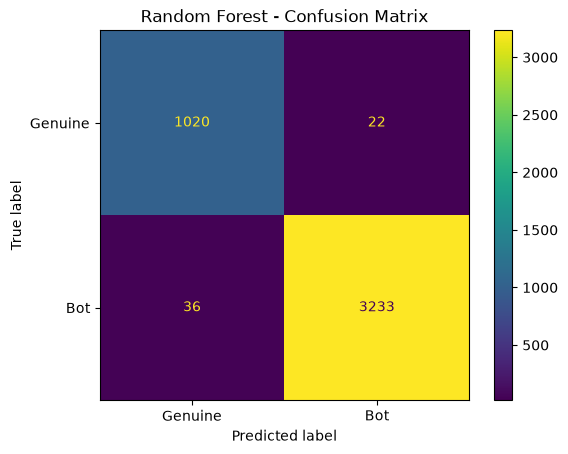

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Bot"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
favourites_count           0.219442
log_favourites_count       0.189653
favorites_per_status       0.168692
statuses_count             0.102987
statuses_per_day           0.091650
log_statuses_count         0.091531
friends_followers_ratio    0.029052
followers_friends_ratio    0.028371
account_age_days           0.020564
log_followers_count        0.014479
friends_count              0.012527
followers_count            0.010558
log_friends_count          0.010548
listed_count               0.005055
log_listed_count           0.004892
dtype: float64


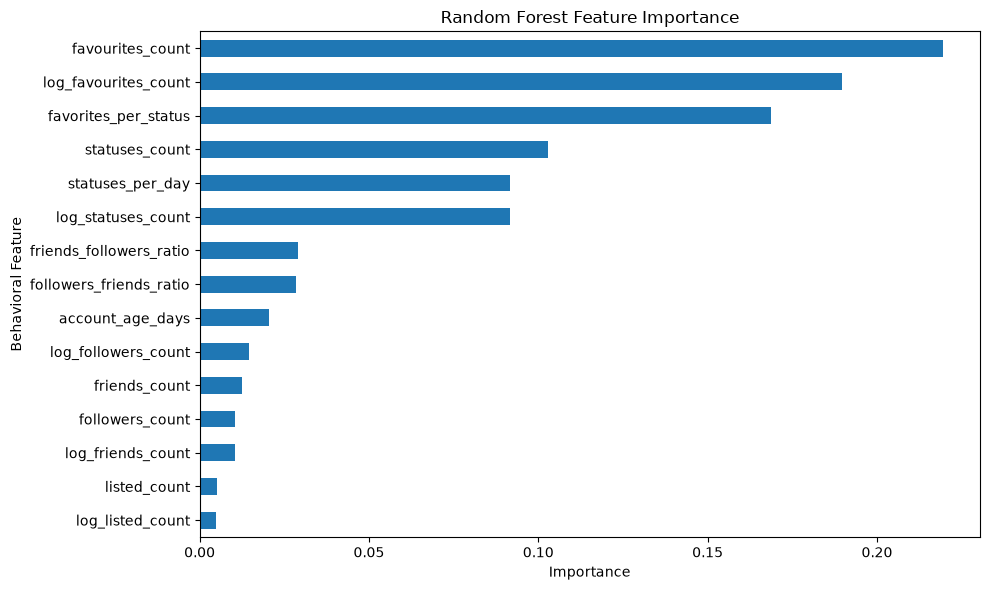

In [17]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Behavioral Feature")
plt.tight_layout()
plt.show()

In [18]:
# Features for ablation experiment
features_without_logs = [
    col for col in X.columns
    if not col.startswith("log_")
]

X_ablation = df[features_without_logs].copy()

print("Original number of features:", X.shape[1])
print("Features after removing log features:", X_ablation.shape[1])
print("\nRemaining features:")
print(features_without_logs)

Original number of features: 15
Features after removing log features: 10

Remaining features:
['statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'account_age_days', 'statuses_per_day', 'followers_friends_ratio', 'friends_followers_ratio', 'favorites_per_status']


In [19]:
from sklearn.model_selection import train_test_split

X_ab_train, X_ab_test, y_ab_train, y_ab_test = train_test_split(
    X_ablation,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Ablation training set:", X_ab_train.shape)
print("Ablation test set:", X_ab_test.shape)

Ablation training set: (10057, 10)
Ablation test set: (4311, 10)


In [20]:
from sklearn.impute import SimpleImputer

ab_imputer = SimpleImputer(strategy="median")

X_ab_train_imputed = ab_imputer.fit_transform(X_ab_train)
X_ab_test_imputed = ab_imputer.transform(X_ab_test)

print("Missing values after imputation:")
print(pd.DataFrame(X_ab_train_imputed).isna().sum().sum())
print(pd.DataFrame(X_ab_test_imputed).isna().sum().sum())

Missing values after imputation:
0
0


In [21]:
rf_ablation = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_ablation.fit(X_ab_train_imputed, y_ab_train)

print("Ablation Random Forest training completed!")

Ablation Random Forest training completed!


In [22]:
y_ab_pred = rf_ablation.predict(X_ab_test_imputed)

print("Ablation predictions completed!")
print("Number of predictions:", len(y_ab_pred))

Ablation predictions completed!
Number of predictions: 4311


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

ab_accuracy = accuracy_score(y_ab_test, y_ab_pred)
ab_precision = precision_score(y_ab_test, y_ab_pred)
ab_recall = recall_score(y_ab_test, y_ab_pred)
ab_f1 = f1_score(y_ab_test, y_ab_pred)

print("10-Feature Ablation Random Forest Performance")
print("=" * 50)
print(f"Accuracy : {ab_accuracy:.4f}")
print(f"Precision: {ab_precision:.4f}")
print(f"Recall   : {ab_recall:.4f}")
print(f"F1-Score : {ab_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    y_ab_test,
    y_ab_pred,
    target_names=["Genuine", "Bot"]
))

10-Feature Ablation Random Forest Performance
Accuracy : 0.9870
Precision: 0.9945
Recall   : 0.9884
F1-Score : 0.9914

Detailed Classification Report:
              precision    recall  f1-score   support

     Genuine       0.96      0.98      0.97      1042
         Bot       0.99      0.99      0.99      3269

    accuracy                           0.99      4311
   macro avg       0.98      0.99      0.98      4311
weighted avg       0.99      0.99      0.99      4311



In [24]:
print("Account types and counts:")
print(df["account_type"].value_counts())

Account types and counts:
account_type
genuine_accounts          3474
social_spambots_2         3457
fake_followers            3351
traditional_spambots_4    1128
traditional_spambots_1    1000
social_spambots_1          991
social_spambots_3          464
traditional_spambots_3     403
traditional_spambots_2     100
Name: count, dtype: int64


In [25]:
# Hold out fake_followers completely from training

held_out_type = "fake_followers"

train_df = df[df["account_type"] != held_out_type].copy()
held_out_df = df[df["account_type"] == held_out_type].copy()

print("Training data:", train_df.shape)
print("Held-out fake followers:", held_out_df.shape)

print("\nTraining account types:")
print(train_df["account_type"].value_counts())

print("\nHeld-out account type:")
print(held_out_df["account_type"].value_counts())

Training data: (11017, 20)
Held-out fake followers: (3351, 20)

Training account types:
account_type
genuine_accounts          3474
social_spambots_2         3457
traditional_spambots_4    1128
traditional_spambots_1    1000
social_spambots_1          991
social_spambots_3          464
traditional_spambots_3     403
traditional_spambots_2     100
Name: count, dtype: int64

Held-out account type:
account_type
fake_followers    3351
Name: count, dtype: int64


In [26]:
# Use the same 15 behavioral features as our baseline

behavior_features = [
    "statuses_count",
    "followers_count",
    "friends_count",
    "favourites_count",
    "listed_count",
    "account_age_days",
    "statuses_per_day",
    "followers_friends_ratio",
    "friends_followers_ratio",
    "favorites_per_status",
    "log_statuses_count",
    "log_followers_count",
    "log_friends_count",
    "log_favourites_count",
    "log_listed_count"
]

# Training data: genuine + known bot types
X_cross_train = train_df[behavior_features]
y_cross_train = train_df["label"]

# Test data: genuine + completely unseen fake followers
X_cross_test = held_out_df[behavior_features]
y_cross_test = held_out_df["label"]

print("Cross-type training shape:", X_cross_train.shape)
print("Cross-type test shape:", X_cross_test.shape)

print("\nTraining labels:")
print(y_cross_train.value_counts())

print("\nHeld-out labels:")
print(y_cross_test.value_counts())

Cross-type training shape: (11017, 15)
Cross-type test shape: (3351, 15)

Training labels:
label
1    7543
0    3474
Name: count, dtype: int64

Held-out labels:
label
1    3351
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

# Split genuine accounts into training and test portions
genuine_df = df[df["account_type"] == "genuine_accounts"].copy()

genuine_train, genuine_test = train_test_split(
    genuine_df,
    test_size=0.30,
    random_state=42,
    stratify=genuine_df["label"]
)

# All non-fake-follower bots remain in training
known_bots_train = df[
    (df["label"] == 1) &
    (df["account_type"] != "fake_followers")
].copy()

# All fake followers remain completely unseen until testing
unseen_bots_test = df[
    df["account_type"] == "fake_followers"
].copy()

# Combine training data
cross_train_df = pd.concat(
    [genuine_train, known_bots_train],
    ignore_index=True
)

# Combine test data
cross_test_df = pd.concat(
    [genuine_test, unseen_bots_test],
    ignore_index=True
)

print("Cross-type training:", cross_train_df.shape)
print("Cross-type testing:", cross_test_df.shape)

print("\nTraining labels:")
print(cross_train_df["label"].value_counts())

print("\nTesting labels:")
print(cross_test_df["label"].value_counts())

print("\nBot types in training:")
print(cross_train_df[cross_train_df["label"] == 1]["account_type"].value_counts())

print("\nBot types in testing:")
print(cross_test_df[cross_test_df["label"] == 1]["account_type"].value_counts())

Cross-type training: (9974, 20)
Cross-type testing: (4394, 20)

Training labels:
label
1    7543
0    2431
Name: count, dtype: int64

Testing labels:
label
1    3351
0    1043
Name: count, dtype: int64

Bot types in training:
account_type
social_spambots_2         3457
traditional_spambots_4    1128
traditional_spambots_1    1000
social_spambots_1          991
social_spambots_3          464
traditional_spambots_3     403
traditional_spambots_2     100
Name: count, dtype: int64

Bot types in testing:
account_type
fake_followers    3351
Name: count, dtype: int64


In [28]:
X_cross_train = cross_train_df[behavior_features]
y_cross_train = cross_train_df["label"]

X_cross_test = cross_test_df[behavior_features]
y_cross_test = cross_test_df["label"]

print("X_train:", X_cross_train.shape)
print("X_test:", X_cross_test.shape)

X_train: (9974, 15)
X_test: (4394, 15)


In [29]:
cross_imputer = SimpleImputer(strategy="median")

X_cross_train_imputed = cross_imputer.fit_transform(X_cross_train)
X_cross_test_imputed = cross_imputer.transform(X_cross_test)

print("Training missing values:",
      pd.DataFrame(X_cross_train_imputed).isna().sum().sum())

print("Testing missing values:",
      pd.DataFrame(X_cross_test_imputed).isna().sum().sum())

Training missing values: 0
Testing missing values: 0


In [30]:
rf_cross = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_cross.fit(
    X_cross_train_imputed,
    y_cross_train
)

print("Cross-type Random Forest training completed!")

Cross-type Random Forest training completed!


In [31]:
y_cross_pred = rf_cross.predict(X_cross_test_imputed)

print("Cross-type predictions completed!")
print("Number of predictions:", len(y_cross_pred))

Cross-type predictions completed!
Number of predictions: 4394


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

cross_accuracy = accuracy_score(y_cross_test, y_cross_pred)
cross_precision = precision_score(y_cross_test, y_cross_pred)
cross_recall = recall_score(y_cross_test, y_cross_pred)
cross_f1 = f1_score(y_cross_test, y_cross_pred)

print("Cross-Type Random Forest Performance")
print("=" * 50)
print(f"Accuracy : {cross_accuracy:.4f}")
print(f"Precision: {cross_precision:.4f}")
print(f"Recall   : {cross_recall:.4f}")
print(f"F1-Score : {cross_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    y_cross_test,
    y_cross_pred,
    target_names=["Genuine", "Bot"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_cross_test, y_cross_pred))

Cross-Type Random Forest Performance
Accuracy : 0.6379
Precision: 0.9911
Recall   : 0.5300
F1-Score : 0.6906

Detailed Classification Report:
              precision    recall  f1-score   support

     Genuine       0.39      0.98      0.56      1043
         Bot       0.99      0.53      0.69      3351

    accuracy                           0.64      4394
   macro avg       0.69      0.76      0.63      4394
weighted avg       0.85      0.64      0.66      4394


Confusion Matrix:
[[1027   16]
 [1575 1776]]
